In [1]:
import os, sys, importlib
import json
import pandas as pd

## merge

In [11]:
import pandas as pd
import json
df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")
print(len(df_all))

RESULTS_FOLDER="results"
IMAGES_FOLDER='images'
path_result_london=os.path.join(RESULTS_FOLDER,f"deepface_results_london.json")
path_result_paris=os.path.join(RESULTS_FOLDER,f"deepface_results_paris.json")

with open(path_result_london, 'r', encoding='utf-8')as f:
    results_london=json.load(f)
    print(len(results_london))
with open(path_result_paris, 'r', encoding='utf-8')as f:
    results_paris=json.load(f)
    print(len(results_paris))

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15144\387673865.py:3: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")


112594
24819
43055


In [55]:
results=[]
results.extend(results_london)
results.extend(results_paris)
print(len(results))
print(results[0])

df_results=pd.DataFrame(results)
print(df_results.columns)
df_results_to_merge=df_results[['host_id',"nb_face", 'host_picture_type',"age_class",'gender',"smile_score",'is_smiling']]
display(df_results_to_merge.head())

67874
{'img_path': '/content/drive/MyDrive/airbnbMM2/host_pic/images/host_pic_london_25051/10005361.jpg', 'host_id': 10005361, 'has_face': 0, 'nb_face': 0, 'face_area_ratio': 0, 'avg_face_prob': 0, 'bbox_list': [], 'clean_score': 0, 'lifestyle_score': 0, 'host_picture_type': 'no_person', 'age': 'unk', 'age_class': 'unk', 'gender': 'unk', 'smile_score': 0, 'is_smiling': 0, 'dominant_emotion': None}
Index(['img_path', 'host_id', 'has_face', 'nb_face', 'face_area_ratio',
       'avg_face_prob', 'bbox_list', 'clean_score', 'lifestyle_score',
       'host_picture_type', 'age', 'age_class', 'gender', 'smile_score',
       'is_smiling', 'dominant_emotion'],
      dtype='object')


,host_id,nb_face,host_picture_type,age_class,gender,smile_score,is_smiling
0,10005361,0,no_person,unk,unk,0.000000,0
1,100076439,0,no_person,unk,unk,0.000000,0
2,100079118,1,pro_style,middle,Woman,96.385880,1
3,10008184,0,no_person,unk,unk,0.000000,0
4,100068787,1,pro_style,middle,Man,0.000003,0


In [57]:
df_results_to_merge['gender'].value_counts(dropna=False)
df_results_to_merge['gender']=df_results_to_merge['gender'].fillna('unk')

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15144\2312114181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_to_merge['gender']=df_results_to_merge['gender'].fillna('unk')


In [58]:
df_results_to_merge.isna().value_counts()


host_id  nb_face  host_picture_type  age_class  gender  smile_score  is_smiling
False    False    False              False      False   False        False         67874
Name: count, dtype: int64

In [59]:
df_all_pic=df_all.merge(df_results_to_merge, left_on="host_id", right_on="host_id", how='left')
print(df_all_pic[['host_id','city','host_picture_type']])

          host_id    city host_picture_type
0            3631   paris        life_style
1          433758   paris         no_person
2            7903   paris        life_style
3            2626   paris         pro_style
4          228508   paris         pro_style
...           ...     ...               ...
112589  506745061  london               NaN
112590  576355034  london               NaN
112591  218825499  london         pro_style
112592  132802067  london         pro_style
112593  509027540  london               NaN

[112594 rows x 3 columns]


In [16]:
df_all_pic.to_csv("../data_all\listings_paris_london2406_pic2.csv", index=False)

## quick modeling

In [17]:
import pandas as pd

path_csv="../data_all\listings_paris_london2406_pic2.csv"
df_all_pic=pd.read_csv(path_csv)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15144\2935264704.py:4: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all_pic=pd.read_csv(path_csv)


In [60]:
df_all_pic_fillna=df_all_pic.copy()

# check
vars=["nb_face",'host_picture_type','age_class','gender','is_smiling']
print(df_all_pic[vars].isna().value_counts())

# # dropna
# print(df_all_pic.host_picture_type.isna().value_counts(dropna=False))
# df_all_pic_dropna=df_all_pic.dropna(subset='host_picture_type')
# print(len(df_all_pic), len(df_all_pic_dropna))


nb_face  host_picture_type  age_class  gender  is_smiling
False    False              False      False   False         106723
True     True               True       True    True            5871
Name: count, dtype: int64


In [61]:

df_all_pic_fillna['host_picture_type']=df_all_pic['host_picture_type'].fillna('no_person')
# df_all_pic_fillna=df_all_pic_dropna.copy()#去掉没有照片的行
df_all_pic_fillna['age_class']=df_all_pic['age_class'].fillna('unk')
df_all_pic_fillna['gender']=df_all_pic['gender'].fillna('unk')
df_all_pic_fillna['is_smiling']=df_all_pic['is_smiling'].fillna(0)
print(df_all_pic_fillna[vars].isna().value_counts())
print(df_all_pic_fillna.host_picture_type.value_counts(dropna=False))


nb_face  host_picture_type  age_class  gender  is_smiling
False    False              False      False   False         106723
True     False              False      False   False           5871
Name: count, dtype: int64
host_picture_type
pro_style     40522
no_person     38711
life_style    33361
Name: count, dtype: int64


In [62]:
print(len(df_all_pic_fillna))
print(df_all_pic_fillna.host_about.isna().value_counts()/len(df_all_pic_fillna))
print(df_all_pic_fillna.lang.value_counts()/len(df_all_pic_fillna))

112594
host_about
True     0.520863
False    0.479137
Name: count, dtype: float64
lang
no_text        0.522364
en             0.328561
fr             0.139537
other_langs    0.009539
Name: count, dtype: float64


In [63]:
df_all_pic_fillna.columns.to_list()


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_ra

,city,ouverture,is_base,coef,se,t,pval,sig
0,paris,1,False,-0.003957,0.001293,-3.060921,0.002207,**
1,london,1,True,0.001610,0.001260,1.278427,0.201101,


authenticité


,city,authenticité,is_base,coef,se,t,pval,sig
0,paris,1,False,0.001175,0.001437,0.817944,0.413391,
1,london,1,True,0.004739,0.001399,3.387696,0.000705,***


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


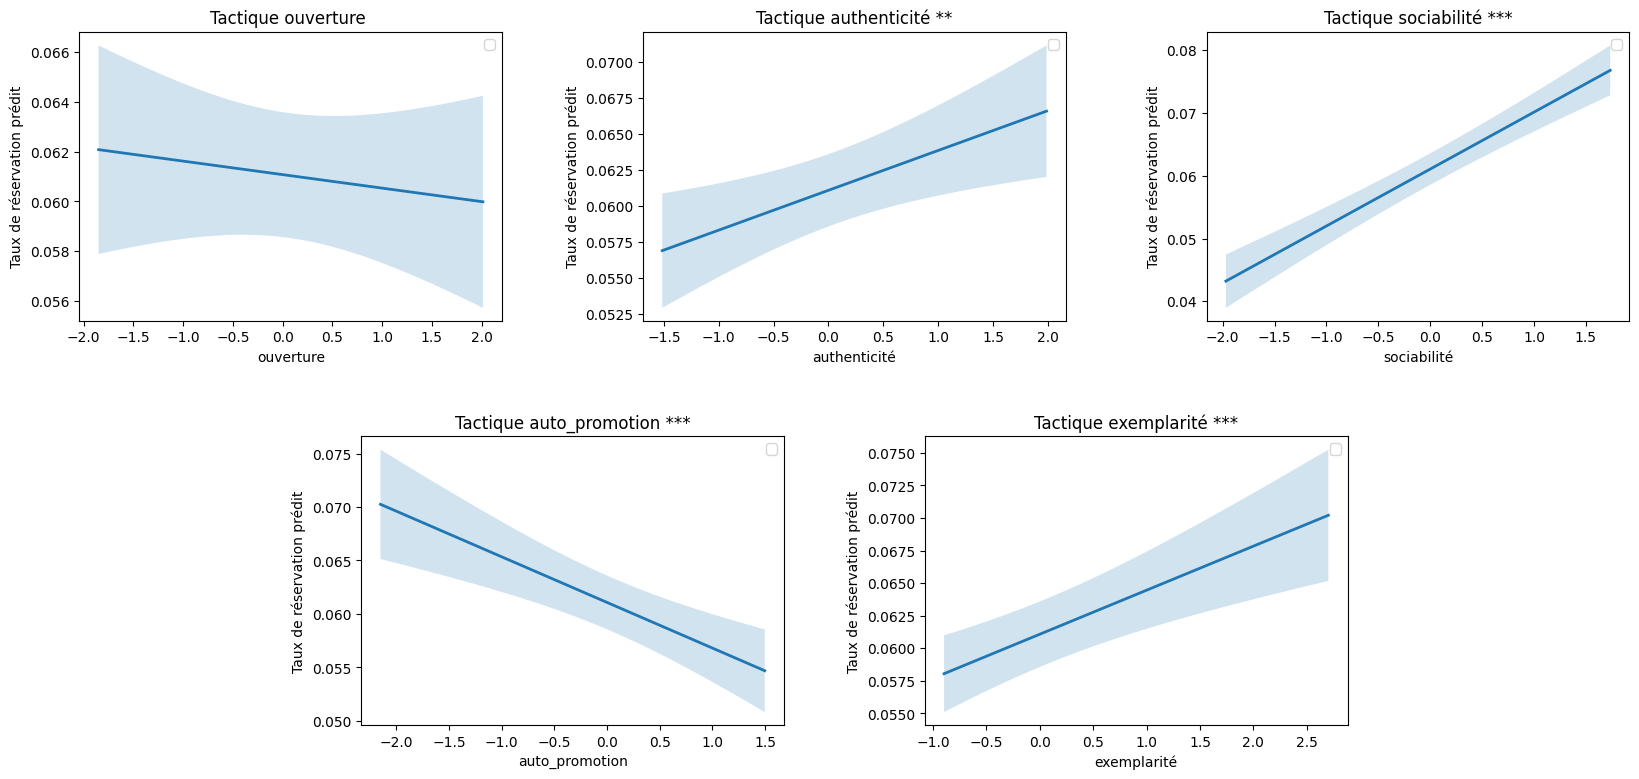

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['city']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(city)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + C(city)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling 

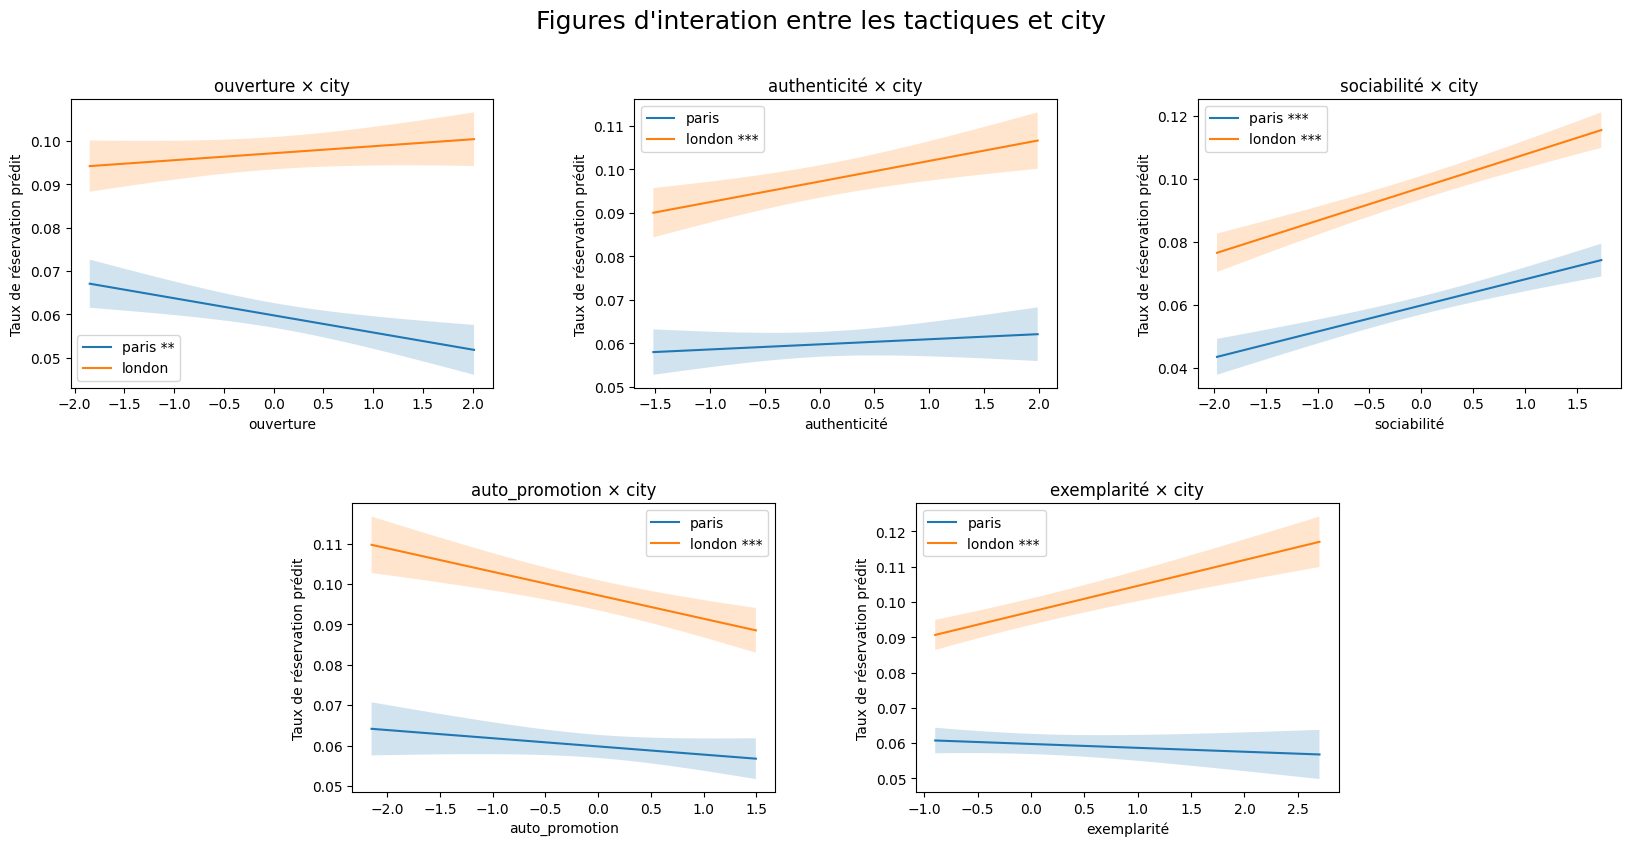

In [66]:
import os, sys, importlib
sys.path.append(os.path.abspath(".."))
import pandas as pd
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", #"host_has_profile_pic",         
    "review_scores_rating", #"number_of_reviews_till_Q",#"reviews_per_month",#"number_of_reviews", #"has_rating", 
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    #'status_changed',# 'old_host_sp_changed',"is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90",
    "room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
            #   "nb_face",
              "host_picture_type", #"smile_score",
              'is_smiling',
            # "gender",
            # "age_class"
              ]

# df_city=df_all_pic_fillna[df_all_pic_fillna['city']=="paris"]
modeling_main(df_input=df_all_pic_fillna, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="city",
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

## 大型事件利好quality策略，对personality无效？
## 对于superhost有不显著积极效果

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'host_picture_type', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'host_picture_type']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type

,city,ouverture,is_base,coef,se,t,pval,sig
0,paris,1,True,-0.004831,0.001171,-4.125973,0.000037,***


authenticité


,city,authenticité,is_base,coef,se,t,pval,sig
0,paris,1,True,0.003319,0.001293,2.566966,0.010262,*


sociabilité


...


 ============================================models table============================================


,Basique,Tactiques,city
C(host_picture_type)[T.no_person],-0.0078***\n(0.0017),-0.0078***\n(0.0017),-0.0012\n(0.0071)
C(host_picture_type)[T.pro_style],0.0060***\n(0.0014),0.0060***\n(0.0014),0.0036***\n(0.0007)
host_picture_type[T.no_person],,,-0.0012\n(0.0071)
host_picture_type[T.pro_style],,,0.0036***\n(0.0007)
gender[T.Woman],,,-0.0032*\n(0.0017)
gender[T.multi],,,0.0051\n(0.0040)
gender[T.unk],,,-0.0029\n(0.0142)
ouverture,,,-0.0048***\n(0.0012)
authenticité,,,0.0033**\n(0.0013)
sociabilité,,,0.0101***\n(0.0011)


,Basique,Tactiques,city
C(host_identity_verified)[T.t],0.0179***\n(0.0023),0.0179***\n(0.0023),0.0157***\n(0.0023)
C(host_is_superhost)[T.t],0.0729***\n(0.0015),0.0729***\n(0.0015),0.0717***\n(0.0015)
C(lang)[T.fr],0.0088***\n(0.0018),0.0088***\n(0.0018),0.0055***\n(0.0020)
C(lang)[T.no_text],0.0032*\n(0.0019),0.0032*\n(0.0019),0.0044**\n(0.0020)
C(lang)[T.other_langs],0.0103*\n(0.0061),0.0103*\n(0.0061),0.0111*\n(0.0061)
C(room_type)[T.Hotel room],-0.0560***\n(0.0069),-0.0560***\n(0.0069),-0.0603***\n(0.0069)
C(room_type)[T.Private room],0.0188***\n(0.0022),0.0188***\n(0.0022),0.0169***\n(0.0022)
C(room_type)[T.Shared room],0.0241**\n(0.0097),0.0241**\n(0.0097),0.0206**\n(0.0097)
C(instant_bookable)[T.t],0.0230***\n(0.0015),0.0230***\n(0.0015),0.0246***\n(0.0015)
review_scores_rating,0.0028\n(0.0020),0.0028\n(0.0020),0.0022\n(0.0020)


===========================================tactics plots============================================
+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + gender



PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'city' is not defined
    booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ openness + authenticity + sociability + self_promotion + exemplification + host_picture_type + is_smiling + gender
                                                                           ^^^^^^^

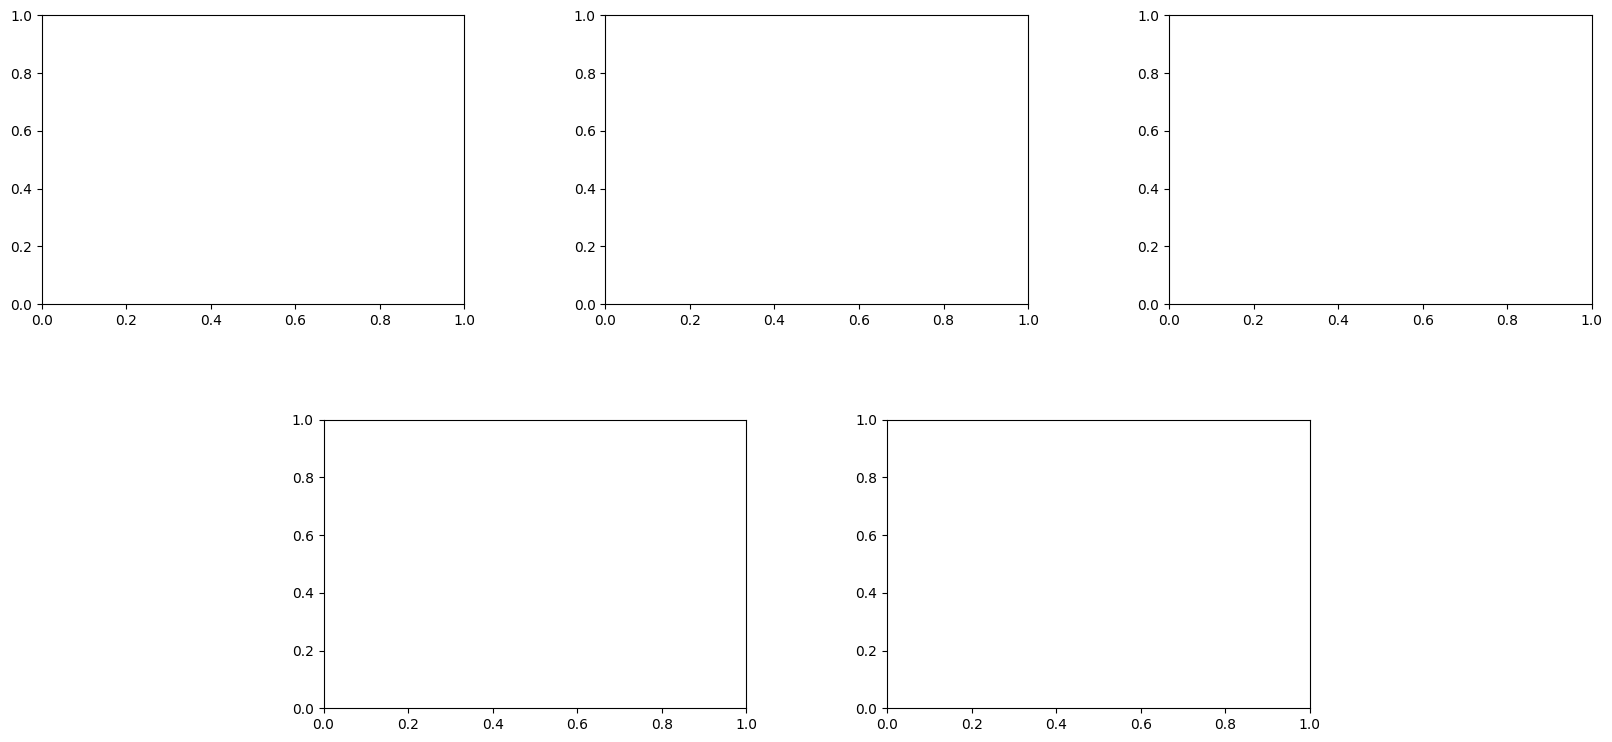

In [9]:
import os, sys, importlib
sys.path.append(os.path.abspath(".."))
import pandas as pd
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", #"host_has_profile_pic",         
    "review_scores_rating", #"number_of_reviews_till_Q",#"reviews_per_month",#"number_of_reviews", #"has_rating", 
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    #'status_changed',# 'old_host_sp_changed',"is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90",
    "room_type", "instant_bookable", #'is_within_1km'
    "host_picture_type"
]  



tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              "host_picture_type",'is_smiling',
             "gender"
            #   "age_class"
              ]


df_paris=df_all_pic_fillna[df_all_pic_fillna['city']=="paris"]
modeling_main(df_input=df_paris, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="city",
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'host_picture_type', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'host_picture_type']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type

,city,ouverture,is_base,coef,se,t,pval,sig
0,paris,1,False,-0.003958,0.001293,-3.062161,0.002198,**
1,london,1,True,0.001657,0.001260,1.315019,0.188506,


authenticité


,city,authenticité,is_base,coef,se,t,pval,sig
0,paris,1,False,0.001221,0.001437,0.849774,0.395452,
1,london,1,True,0.004668,0.001399,3.335807,0.000851,***


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + gender



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + gender



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


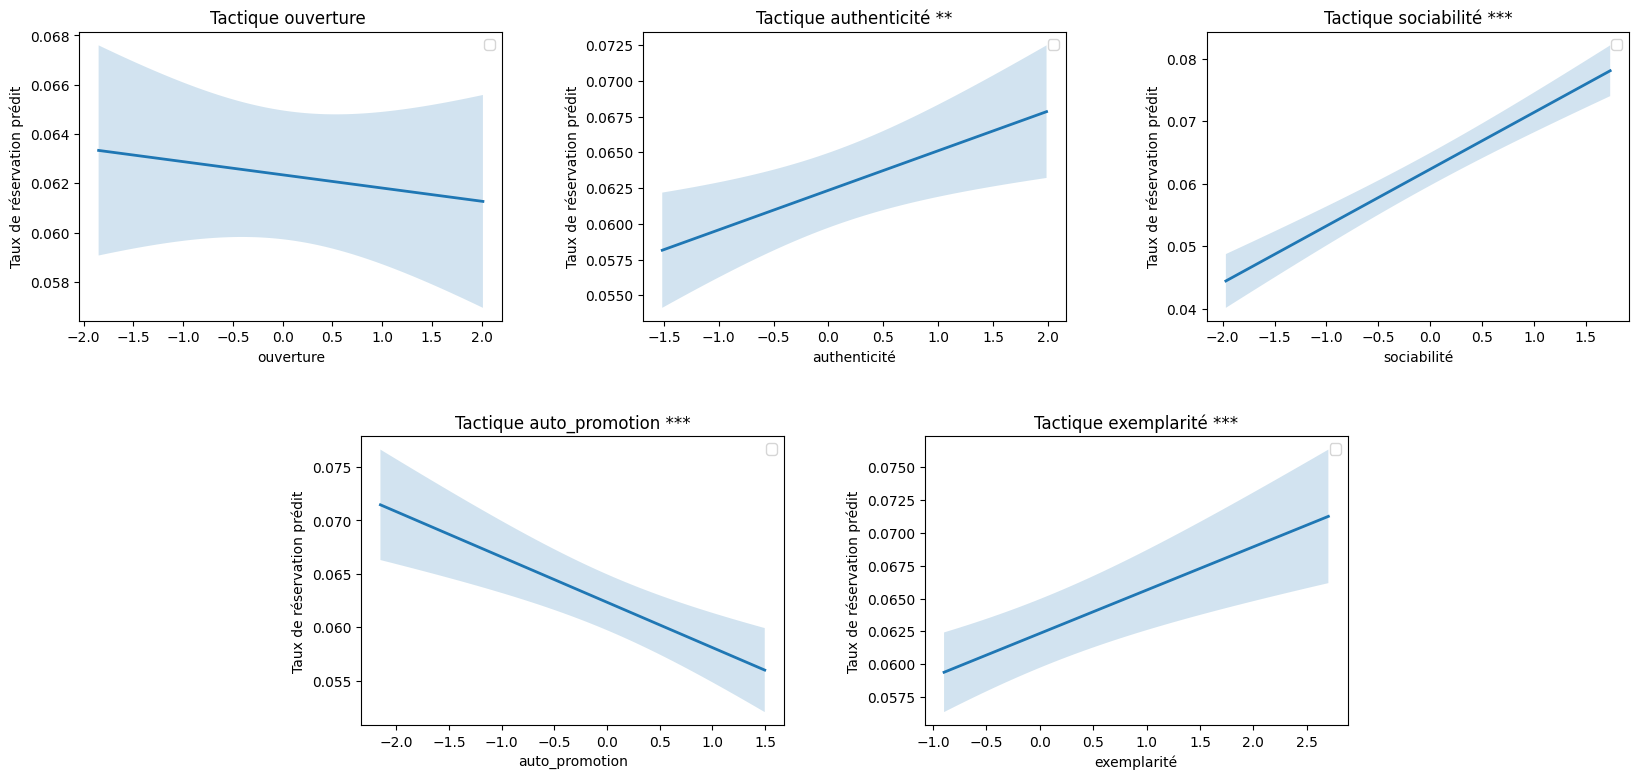

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['city']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'host_picture_type']

group col str:  C(city)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + gender + C(city)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + is_smiling + gender)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + C(host_picture_type) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + 

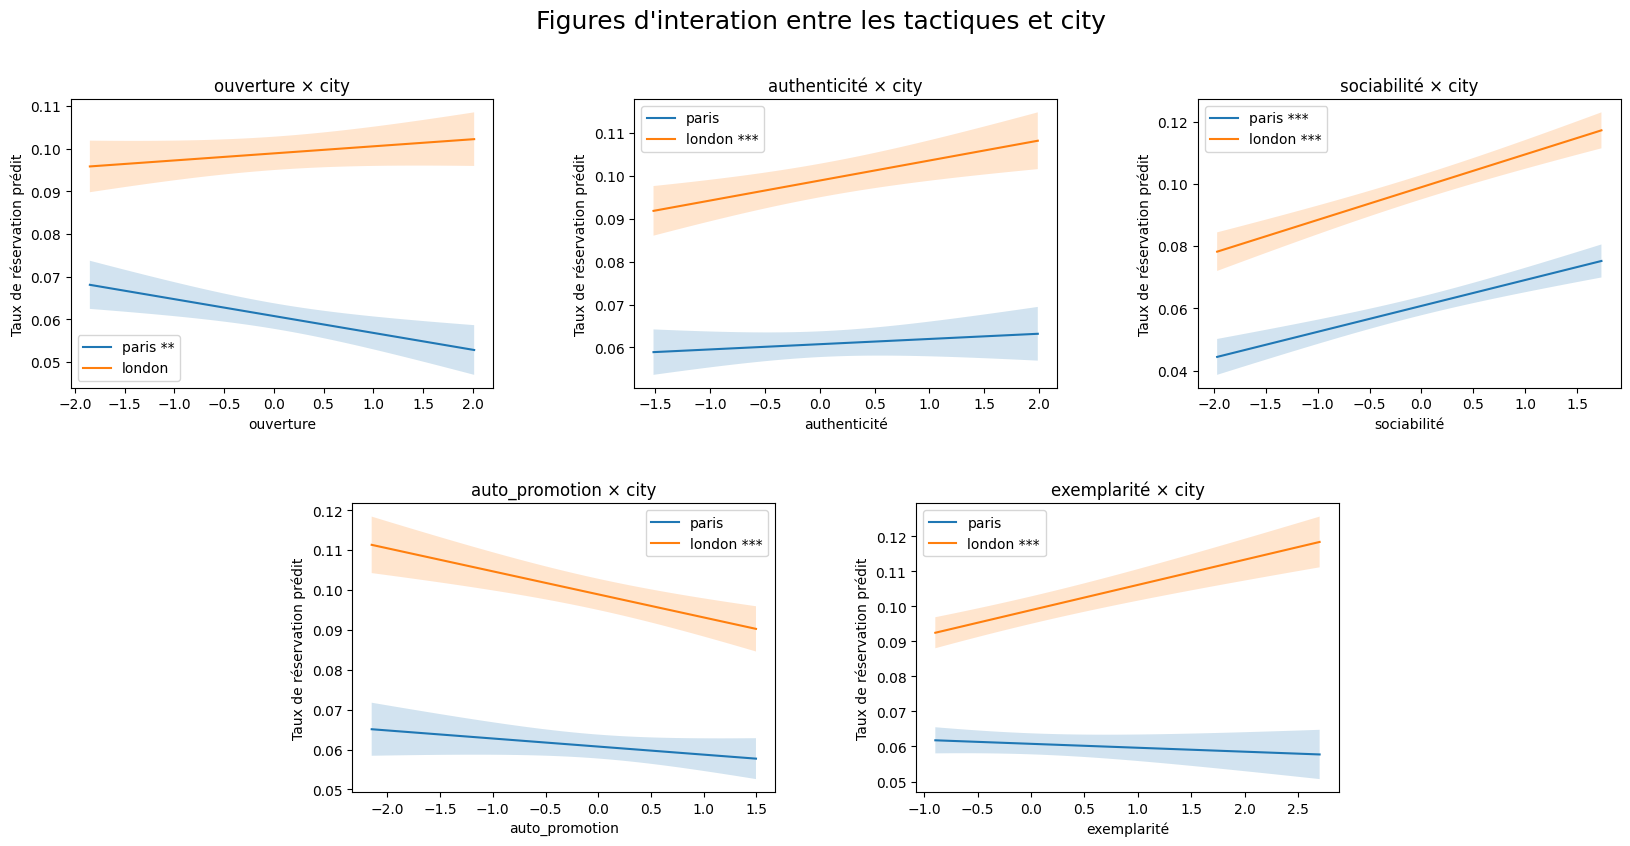

In [7]:
import os, sys, importlib
sys.path.append(os.path.abspath(".."))
import pandas as pd
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", #"host_has_profile_pic",         
    "review_scores_rating", #"number_of_reviews_till_Q",#"reviews_per_month",#"number_of_reviews", #"has_rating", 
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    #'status_changed',# 'old_host_sp_changed',"is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90",
    "room_type", "instant_bookable", #'is_within_1km'
    "host_picture_type"
]  



tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              "host_picture_type",'is_smiling',
             "gender"
            #   "age_class"
              ]

modeling_main(df_input=df_all_pic_fillna, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="city",
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

## 利好auto，无论是视觉还是文本？